# Kaggle Predict F1 Pit Stops: Model Optimization and Ensemble

This notebook is the primary submission workflow. It tunes LightGBM, validates competing feature sets, checks whether XGBoost improves the out-of-fold blend, studies calibration, and writes the final probability submission.

## 1. Setup and Configuration

This section defines the modeling environment for optimization: metrics, preprocessing helpers, fold count, fast/full mode, and the starting selected feature set. The shared helpers keep tuning, feature validation, blending, and final training on the same metric and preprocessing definitions.

In [1]:
import gc
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score
from sklearn.metrics import log_loss
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import ParameterSampler
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "legend.frameon": False,
    }
)

RANDOM_STATE = 42
TARGET = "PitNextLap"
ID_COL = "id"

# Set True for quick notebook iteration. Set False for final Kaggle runs.
RUN_FAST = True
FAST_SAMPLE_SIZE = 180_000
N_SPLITS = 5
SELECTED_FEATURE_SET = "safe_plus_ratios_no_driver"


def evaluate_predictions(y_true, y_pred) -> dict[str, float]:
    """Calculate ranking and probability metrics for OOF predictions."""
    y_pred = np.clip(y_pred, 1e-6, 1 - 1e-6)
    return {
        "roc_auc": roc_auc_score(y_true, y_pred),
        "average_precision": average_precision_score(y_true, y_pred),
        "log_loss": log_loss(y_true, y_pred),
    }


def get_feature_columns(
    df: pd.DataFrame,
    target: str = TARGET,
    id_col: str = ID_COL,
) -> tuple[list[str], list[str]]:
    """Split a dataframe into numeric and categorical feature columns."""
    drop_cols = [c for c in [target, id_col] if c in df.columns]
    features = df.drop(columns=drop_cols)
    cat_cols = (
        features.select_dtypes(include=["object", "category"])
        .columns.tolist()
    )
    num_cols = [c for c in features.columns if c not in cat_cols]
    return num_cols, cat_cols


def make_tree_preprocessor(df: pd.DataFrame) -> ColumnTransformer:
    """Build preprocessing for tree models with ordinal categoricals."""
    num_cols, cat_cols = get_feature_columns(df)
    numeric_pipe = Pipeline([("imputer", SimpleImputer(strategy="median"))])
    categorical_pipe = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "ordinal",
                OrdinalEncoder(
                    handle_unknown="use_encoded_value",
                    unknown_value=-1,
                ),
            ),
        ]
    )
    return ColumnTransformer(
        [
            ("num", numeric_pipe, num_cols),
            ("cat", categorical_pipe, cat_cols),
        ],
        remainder="drop",
    )


## 2. Load Data

The data-loading step reads the competition inputs from the fixed Kaggle input path, reduces memory usage, and prepares an evaluation frame. Fast mode keeps tuning loops practical; full mode can be used when confirming the selected configuration.

In [2]:
def reduce_memory_usage(df: pd.DataFrame) -> pd.DataFrame:
    """Downcast dataframe columns to reduce notebook memory usage."""
    out = df.copy()
    for col in out.columns:
        dtype = out[col].dtype
        if pd.api.types.is_integer_dtype(dtype):
            out[col] = pd.to_numeric(out[col], downcast="integer")
        elif pd.api.types.is_float_dtype(dtype):
            out[col] = pd.to_numeric(out[col], downcast="float")
        elif pd.api.types.is_object_dtype(dtype):
            nunique = out[col].nunique(dropna=False)
            if nunique / max(len(out), 1) < 0.5:
                out[col] = out[col].astype("category")
    return out


DATA_DIR = Path("/kaggle/input/competitions/playground-series-s6e5")
OUTPUT_DIR = Path("/kaggle/working")

train = reduce_memory_usage(pd.read_csv(DATA_DIR / "train.csv"))
test = reduce_memory_usage(pd.read_csv(DATA_DIR / "test.csv"))
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

print(f"DATA_DIR: {DATA_DIR}")
print(f"train: {train.shape}")
print(f"test: {test.shape}")
print(f"target positive rate: {train[TARGET].mean():.5f}")
train.head()

if RUN_FAST and len(train) > FAST_SAMPLE_SIZE:
    train_eval = (
        train.groupby(TARGET, group_keys=False)
        .apply(
            lambda part: part.sample(
                frac=min(1.0, FAST_SAMPLE_SIZE / len(train)),
                random_state=RANDOM_STATE,
            )
        )
        .sample(frac=1.0, random_state=RANDOM_STATE)
        .reset_index(drop=True)
    )
else:
    train_eval = train.copy()
print("train_eval:", train_eval.shape)


DATA_DIR: /kaggle/input/competitions/playground-series-s6e5
train: (439140, 16)
test: (188165, 15)
target positive rate: 0.19898
train_eval: (180000, 16)


## 3. Feature Sets

This section defines the candidate feature families. The raw set provides a baseline, safe engineered features add row-level strategy context, ratio features capture tyre and race progress relationships, and lifecycle features test a broader reconstruction of tyre age behavior.

In [3]:
COMPOUND_STINT_MEDIANS = {
    "SOFT": 14.0,
    "MEDIUM": 17.0,
    "HARD": 23.0,
    "INTERMEDIATE": 16.0,
    "WET": 14.0,
}

COMPOUND_HARDNESS = {
    "SOFT": 1,
    "MEDIUM": 2,
    "HARD": 3,
    "INTERMEDIATE": 1,
    "WET": 0,
}


def add_features(
    df: pd.DataFrame,
    include_safe: bool = True,
    include_ratios: bool = True,
    include_lifecycle: bool = False,
) -> pd.DataFrame:
    """Add row-safe strategy features for feature-set validation."""
    out = df.copy()
    eps = 1e-6

    if include_safe and {"LapNumber", "RaceProgress"}.issubset(out.columns):
        out["EstimatedRaceLaps"] = (
            out["LapNumber"] / out["RaceProgress"].clip(lower=eps)
        )
        out["EstimatedLapsRemaining"] = (
            out["EstimatedRaceLaps"] - out["LapNumber"]
        )
        out["LapNumber_x_RaceProgress"] = (
            out["LapNumber"] * out["RaceProgress"]
        )

    if include_ratios and {"TyreLife", "LapNumber"}.issubset(out.columns):
        out["TyreLife_to_LapNumber"] = (
            out["TyreLife"] / out["LapNumber"].clip(lower=eps)
        )

    if include_ratios and {"TyreLife", "EstimatedRaceLaps"}.issubset(out.columns):
        out["TyreLife_to_EstimatedRaceLaps"] = (
            out["TyreLife"] / out["EstimatedRaceLaps"].clip(lower=eps)
        )

    if include_safe and {"LapTime (s)", "LapTime_Delta"}.issubset(out.columns):
        out["LapTime_plus_Delta"] = out["LapTime (s)"] + out["LapTime_Delta"]
        out["AbsLapTime_Delta"] = out["LapTime_Delta"].abs()

    if include_safe and {"Position", "Position_Change"}.issubset(out.columns):
        out["PreviousPositionApprox"] = out["Position"] - out["Position_Change"]
        out["AbsPosition_Change"] = out["Position_Change"].abs()

    if include_safe and "Compound" in out.columns:
        compound = out["Compound"].astype(str)
        out["IsSoft"] = (compound == "SOFT").astype("int8")
        out["IsMedium"] = (compound == "MEDIUM").astype("int8")
        out["IsHard"] = (compound == "HARD").astype("int8")
        out["IsWetOrIntermediate"] = compound.isin(
            ["WET", "INTERMEDIATE"]
        ).astype("int8")

    if include_lifecycle and {"Compound", "TyreLife"}.issubset(out.columns):
        compound = out["Compound"].astype(str)
        out["ExpectedStint"] = (
            compound.map(COMPOUND_STINT_MEDIANS).fillna(17.0).astype("float32")
        )
        out["TyreLife_Normalized"] = (
            out["TyreLife"] / out["ExpectedStint"].clip(lower=eps)
        )
        out["TyreLife_sq"] = out["TyreLife"] ** 2
        out["TyreLife_sqrt"] = np.sqrt(out["TyreLife"].clip(lower=0))
        out["TyreLife_log1p"] = np.log1p(out["TyreLife"].clip(lower=0))
        out["Compound_Hardness"] = (
            compound.map(COMPOUND_HARDNESS).fillna(2).astype("int8")
        )
        out["TyreLife_x_Hardness"] = out["TyreLife"] * out["Compound_Hardness"]
        out["Norm_x_Hardness"] = (
            out["TyreLife_Normalized"] * out["Compound_Hardness"]
        )
        out["Is_Fresh"] = (out["TyreLife"] <= 3).astype("int8")
        out["Is_Old"] = (out["TyreLife"] > 20).astype("int8")
        out["Is_VeryOld"] = (out["TyreLife"] > 40).astype("int8")

    if include_lifecycle and "Stint" in out.columns:
        out["Is_FirstStint"] = (out["Stint"] == 1).astype("int8")
        out["Stint_x_Normalized"] = (
            out["Stint"] * out.get("TyreLife_Normalized", 0)
        )
        out["Stint2_x_Old"] = (
            (out["Stint"] == 2) & (out.get("Is_Old", 0) == 1)
        ).astype("int8")

    if include_lifecycle and {
        "Cumulative_Degradation",
        "TyreLife",
    }.issubset(out.columns):
        out["DegRate"] = (
            out["Cumulative_Degradation"] / (out["TyreLife"] + 1)
        )
        if "Compound_Hardness" in out.columns:
            out["DegRate_x_Hardness"] = (
                out["DegRate"] * out["Compound_Hardness"]
            )

    if include_lifecycle and "RaceProgress" in out.columns:
        out["Early_Race"] = (out["RaceProgress"] < 0.25).astype("int8")
        out["Late_Race"] = (out["RaceProgress"] >= 0.75).astype("int8")
        out["VeryLate_Race"] = (out["RaceProgress"] >= 0.90).astype("int8")
        if "TyreLife" in out.columns:
            out["RaceProgress_x_TyreLife"] = (
                out["RaceProgress"] * out["TyreLife"]
            )
        if "TyreLife_Normalized" in out.columns:
            out["RaceProgress_x_Norm"] = (
                out["RaceProgress"] * out["TyreLife_Normalized"]
            )
        if {"Late_Race", "Is_Old"}.issubset(out.columns):
            out["Late_x_OldTyre"] = out["Late_Race"] * out["Is_Old"]
        if {"VeryLate_Race", "Is_VeryOld"}.issubset(out.columns):
            out["VeryLate_x_VeryOld"] = (
                out["VeryLate_Race"] * out["Is_VeryOld"]
            )

    if include_lifecycle and {"ExpectedStint", "TyreLife"}.issubset(out.columns):
        out["Laps_Until_Due"] = out["ExpectedStint"] - out["TyreLife"]
        out["Overdue"] = (out["Laps_Until_Due"] < 0).astype("int8")

    if include_lifecycle and {"Position", "TyreLife"}.issubset(out.columns):
        out["Position_x_TyreLife"] = out["Position"] * out["TyreLife"]

    if include_lifecycle and "LapTime_Delta" in out.columns:
        out["LapDelta_sq"] = out["LapTime_Delta"] ** 2
        out["LapDelta_extreme"] = (out["LapTime_Delta"].abs() > 10).astype("int8")

    if include_lifecycle and "Year" in out.columns:
        out["Is_2025"] = (out["Year"] == 2025).astype("int8")

    return reduce_memory_usage(out)

feature_set_configs = {
    "raw": {
        "include_safe": False,
        "include_ratios": False,
        "include_lifecycle": False,
        "drop_cols": [],
    },
    "safe_engineered": {
        "include_safe": True,
        "include_ratios": False,
        "include_lifecycle": False,
        "drop_cols": [],
    },
    "safe_plus_ratios": {
        "include_safe": True,
        "include_ratios": True,
        "include_lifecycle": False,
        "drop_cols": [],
    },
    "safe_plus_ratios_no_driver": {
        "include_safe": True,
        "include_ratios": True,
        "include_lifecycle": False,
        "drop_cols": ["Driver"],
    },
    "safe_plus_ratios_no_pitstop": {
        "include_safe": True,
        "include_ratios": True,
        "include_lifecycle": False,
        "drop_cols": ["PitStop"],
    },
    "safe_plus_ratios_lifecycle": {
        "include_safe": True,
        "include_ratios": True,
        "include_lifecycle": True,
        "drop_cols": ["ExpectedStint"],
    },
    "safe_plus_ratios_lifecycle_no_driver": {
        "include_safe": True,
        "include_ratios": True,
        "include_lifecycle": True,
        "drop_cols": ["Driver", "ExpectedStint"],
    },
    "safe_plus_ratios_lifecycle_no_pitstop": {
        "include_safe": True,
        "include_ratios": True,
        "include_lifecycle": True,
        "drop_cols": ["PitStop", "ExpectedStint"],
    },
}


def prepare_feature_set(df: pd.DataFrame, feature_set: str) -> pd.DataFrame:
    """Build one configured feature set and drop excluded columns."""
    config = feature_set_configs[feature_set]
    out = add_features(
        df,
        include_safe=config["include_safe"],
        include_ratios=config["include_ratios"],
        include_lifecycle=config.get("include_lifecycle", False),
    )
    drop_cols = [c for c in config.get("drop_cols", []) if c in out.columns]
    return out.drop(columns=drop_cols)

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)


## 4. LightGBM Tuning

LightGBM is tuned with a focused parameter sample around learning rate, tree size, child constraints, sampling, regularization, and bin count. The search optimizes out-of-fold probability performance while keeping the parameter space small enough to iterate.

In [4]:
base_lgbm_params = {
    "objective": "binary",
    "n_estimators": 900 if RUN_FAST else 1800,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbose": -1,
}

param_grid = {
    "learning_rate": [0.015, 0.02, 0.03, 0.04],
    "num_leaves": [63, 95, 127],
    "min_child_samples": [60, 100, 150],
    "subsample": [0.85, 0.95, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0],
    "reg_alpha": [0.03, 0.1, 1.0],
    "reg_lambda": [1.0, 5.0, 10.0],
    "max_bin": [127, 255],
}
N_ITER = 8 if RUN_FAST else 25
candidate_params = list(
    ParameterSampler(param_grid, n_iter=N_ITER, random_state=RANDOM_STATE)
)


def cv_lgbm_params(
    params: dict,
    feature_set: str = SELECTED_FEATURE_SET,
) -> dict[str, float]:
    """Evaluate one LightGBM parameter set with OOF predictions."""
    data = prepare_feature_set(train_eval, feature_set)
    X = data.drop(columns=[TARGET])
    y = data[TARGET].astype("int8")
    oof = np.zeros(len(X), dtype=np.float32)
    start = time.time()
    for train_idx, valid_idx in cv.split(X, y):
        X_train_raw, X_valid_raw = X.iloc[train_idx], X.iloc[valid_idx]
        y_train = y.iloc[train_idx]
        preprocessor = make_tree_preprocessor(X_train_raw)
        X_train = preprocessor.fit_transform(X_train_raw)
        X_valid = preprocessor.transform(X_valid_raw)
        model = LGBMClassifier(**base_lgbm_params, **params)
        model.fit(X_train, y_train)
        oof[valid_idx] = model.predict_proba(X_valid)[:, 1]
        del preprocessor, X_train, X_valid, model
        gc.collect()
    scores = evaluate_predictions(y, oof)
    scores.update(params)
    scores["fit_seconds"] = time.time() - start
    return scores


tuning_results = (
    pd.DataFrame([cv_lgbm_params(params) for params in candidate_params])
    .sort_values("roc_auc", ascending=False)
    .reset_index(drop=True)
)
tuning_results.head(10)


,roc_auc,average_precision,log_loss,subsample,reg_lambda,reg_alpha,num_leaves,min_child_samples,max_bin,learning_rate,colsample_bytree,fit_seconds
0,0.947210,0.804890,0.229489,0.95,10.0,0.03,127,150,255,0.015,0.8,80.131840
1,0.947171,0.804454,0.229528,1.00,5.0,1.00,95,100,255,0.020,0.8,66.435719
2,0.946875,0.803146,0.230098,0.85,10.0,0.10,95,100,255,0.030,1.0,66.425132
3,0.946840,0.802598,0.230234,1.00,5.0,0.10,63,150,127,0.030,0.9,52.028342
4,0.946785,0.801899,0.230427,1.00,10.0,0.10,95,60,127,0.040,1.0,60.873692
5,0.946727,0.802716,0.230412,0.95,10.0,0.03,63,100,255,0.030,1.0,55.602698
6,0.946716,0.801959,0.230590,0.95,1.0,1.00,95,100,255,0.040,0.9,59.918657
7,0.945872,0.799404,0.232948,0.95,1.0,0.10,127,100,255,0.040,1.0,68.638276


## 5. Feature Validation

Using the best tuned LightGBM parameters, this section compares feature sets under the same validation design. This isolates whether extra engineered columns improve the model or simply add redundant/noisy variation.

In [5]:
INT_LGBM_PARAMS = {
    "num_leaves",
    "min_child_samples",
    "max_bin",
    "n_estimators",
    "max_depth",
}


def clean_lgbm_params(params: dict) -> dict:
    """Convert sampled LightGBM parameters back to Python scalar types."""
    cleaned = {}
    for key, value in params.items():
        if key in INT_LGBM_PARAMS and pd.notna(value):
            cleaned[key] = int(value)
        elif isinstance(value, (np.floating, float)):
            cleaned[key] = float(value)
        else:
            cleaned[key] = value
    return cleaned

best_lgbm_params = clean_lgbm_params(
    {key: tuning_results.iloc[0][key] for key in param_grid.keys()}
)
print(best_lgbm_params)


def cv_feature_set(feature_set: str) -> dict[str, float]:
    """Evaluate one feature set with the tuned LightGBM parameters."""
    data = prepare_feature_set(train_eval, feature_set)
    X = data.drop(columns=[TARGET])
    y = data[TARGET].astype("int8")
    oof = np.zeros(len(X), dtype=np.float32)
    for train_idx, valid_idx in cv.split(X, y):
        X_train_raw, X_valid_raw = X.iloc[train_idx], X.iloc[valid_idx]
        y_train = y.iloc[train_idx]
        preprocessor = make_tree_preprocessor(X_train_raw)
        X_train = preprocessor.fit_transform(X_train_raw)
        X_valid = preprocessor.transform(X_valid_raw)
        model = LGBMClassifier(**base_lgbm_params, **best_lgbm_params)
        model.fit(X_train, y_train)
        oof[valid_idx] = model.predict_proba(X_valid)[:, 1]
        del preprocessor, X_train, X_valid, model
        gc.collect()
    scores = evaluate_predictions(y, oof)
    scores.update({"feature_set": feature_set, "n_features": X.shape[1]})
    return scores


feature_results = (
    pd.DataFrame([cv_feature_set(fs) for fs in feature_set_configs])
    .sort_values("roc_auc", ascending=False)
    .reset_index(drop=True)
)
feature_results


{'learning_rate': 0.015, 'num_leaves': 127, 'min_child_samples': 150, 'subsample': 0.95, 'colsample_bytree': 0.8, 'reg_alpha': 0.03, 'reg_lambda': 10.0, 'max_bin': 255}


,roc_auc,average_precision,log_loss,feature_set,n_features
0,0.947210,0.804890,0.229489,safe_plus_ratios_no_driver,27
1,0.947182,0.804994,0.229586,safe_plus_ratios,28
2,0.946601,0.802247,0.230771,safe_plus_ratios_lifecycle,56
3,0.946541,0.802326,0.230818,safe_plus_ratios_lifecycle_no_driver,55
4,0.946478,0.802647,0.231006,safe_plus_ratios_no_pitstop,27
5,0.946158,0.802772,0.231953,safe_engineered,26
6,0.945763,0.799609,0.232393,safe_plus_ratios_lifecycle_no_pitstop,55
7,0.945481,0.799965,0.233443,raw,15


## 6. LightGBM + XGBoost Blend

XGBoost is evaluated as a blend partner because it is strong in the baseline notebook and may make different errors. The blend search uses out-of-fold predictions, so the selected weight reflects validation behavior rather than test-set guesswork.

In [6]:
selected_feature_set = feature_results.iloc[0]["feature_set"]
data = prepare_feature_set(train_eval, selected_feature_set)
X = data.drop(columns=[TARGET])
y = data[TARGET].astype("int8")

xgb_params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "n_estimators": 700 if RUN_FAST else 1400,
    "learning_rate": 0.025,
    "max_depth": 7,
    "min_child_weight": 8,
    "subsample": 0.85,
    "colsample_bytree": 0.9,
    "reg_alpha": 0.1,
    "reg_lambda": 3.0,
    "tree_method": "hist",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}


def cv_model(factory) -> np.ndarray:
    """Generate OOF predictions from a model factory."""
    oof = np.zeros(len(X), dtype=np.float32)
    for train_idx, valid_idx in cv.split(X, y):
        X_train_raw, X_valid_raw = X.iloc[train_idx], X.iloc[valid_idx]
        y_train = y.iloc[train_idx]
        preprocessor = make_tree_preprocessor(X_train_raw)
        X_train = preprocessor.fit_transform(X_train_raw)
        X_valid = preprocessor.transform(X_valid_raw)
        model = factory()
        model.fit(X_train, y_train)
        oof[valid_idx] = model.predict_proba(X_valid)[:, 1]
        del preprocessor, X_train, X_valid, model
        gc.collect()
    return oof


lgbm_oof = cv_model(
    lambda: LGBMClassifier(**base_lgbm_params, **best_lgbm_params)
)
xgb_oof = cv_model(lambda: XGBClassifier(**xgb_params))
blend_rows = []
for w in np.linspace(0, 1, 21):
    pred = w * lgbm_oof + (1 - w) * xgb_oof
    scores = evaluate_predictions(y, pred)
    scores.update({"lgbm_weight": w, "xgb_weight": 1 - w})
    blend_rows.append(scores)
blend_results = (
    pd.DataFrame(blend_rows)
    .sort_values("roc_auc", ascending=False)
    .reset_index(drop=True)
)
blend_results.head(10)


,roc_auc,average_precision,log_loss,lgbm_weight,xgb_weight
0,0.947210,0.804890,0.229489,1.00,0.00
1,0.947203,0.804924,0.229516,0.95,0.05
2,0.947190,0.804922,0.229558,0.90,0.10
3,0.947169,0.804903,0.229614,0.85,0.15
4,0.947142,0.804864,0.229685,0.80,0.20
5,0.947108,0.804790,0.229770,0.75,0.25
6,0.947066,0.804693,0.229869,0.70,0.30
7,0.947017,0.804560,0.229982,0.65,0.35
8,0.946962,0.804408,0.230109,0.60,0.40
9,0.946899,0.804233,0.230251,0.55,0.45


## 7. Calibration and Error Analysis

This section checks whether predicted probabilities match observed pit rates across deciles and important slices. The goal is to identify whether remaining errors are global, concentrated in high-risk predictions, or tied to race, compound, stint, or race-progress context.

,prediction_bin,rows,predicted_rate,actual_rate,calibration_gap
0,"(-0.000701, 0.0012]",18000,0.000860,0.000611,0.000249
1,"(0.0012, 0.0024]",18000,0.001685,0.000889,0.000796
2,"(0.0024, 0.00582]",18000,0.003931,0.003333,0.000598
3,"(0.00582, 0.011]",18000,0.008229,0.005500,0.002729
4,"(0.011, 0.0204]",18000,0.015003,0.011833,0.003170
5,"(0.0204, 0.0536]",18000,0.032612,0.030722,0.001890
6,"(0.0536, 0.202]",18000,0.114972,0.122333,-0.007361
7,"(0.202, 0.48]",18000,0.335902,0.335778,0.000125
8,"(0.48, 0.748]",18000,0.621837,0.619000,0.002837
9,"(0.748, 0.98]",18000,0.849116,0.859833,-0.010717


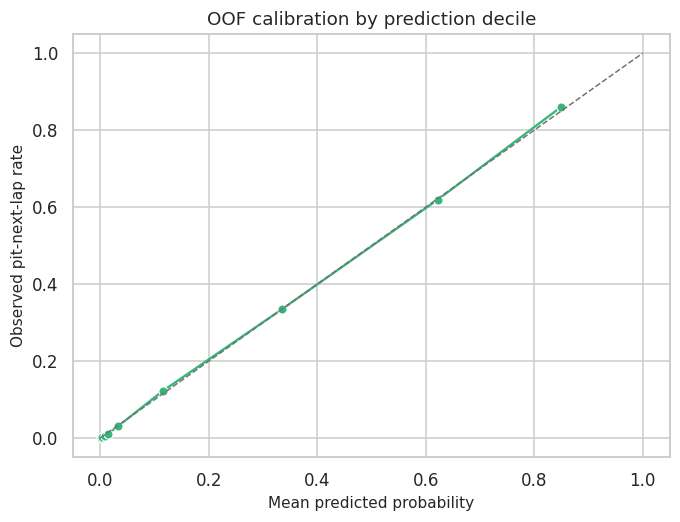

,top_pct,threshold,selected_rows,precision,recall
0,0.5,0.946852,900,0.968889,0.024346
1,1.0,0.931198,1800,0.952222,0.047854
2,2.0,0.907037,3600,0.940833,0.094564
3,5.0,0.847588,9000,0.907556,0.228048
4,10.0,0.747929,18000,0.859833,0.432113
5,20.0,0.480328,36000,0.739417,0.743195


,slice,value,rows,actual_rate,predicted_rate,calibration_gap,roc_auc
17,Race,Chinese Grand Prix,3021,0.390268,0.376840,-0.013428,0.962233
14,Race,Belgian Grand Prix,3610,0.288643,0.278676,-0.009967,0.952632
23,Race,Japanese Grand Prix,5362,0.207199,0.199029,-0.008169,0.937201
21,Race,Hungarian Grand Prix,9295,0.242173,0.235981,-0.006192,0.938942
27,Race,Monaco Grand Prix,8751,0.351731,0.346652,-0.005079,0.962769
30,Race,Saudi Arabian Grand Prix,7356,0.228793,0.223820,-0.004972,0.967101
24,Race,Las Vegas Grand Prix,5143,0.225160,0.220265,-0.004895,0.959898
22,Race,Italian Grand Prix,8151,0.125138,0.129504,0.004366,0.956693
11,Race,Austrian Grand Prix,8715,0.191165,0.187063,-0.004102,0.937246
28,Race,Pre-Season Testing,9179,0.144678,0.148475,0.003796,0.952959


In [7]:
best_blend = blend_results.iloc[0]
best_oof = (
    best_blend["lgbm_weight"] * lgbm_oof
    + best_blend["xgb_weight"] * xgb_oof
)

oof_diagnostics = X.copy()
oof_diagnostics["target"] = y.to_numpy()
oof_diagnostics["prediction"] = np.clip(best_oof, 1e-6, 1 - 1e-6)
oof_diagnostics["prediction_bin"] = pd.qcut(
    oof_diagnostics["prediction"],
    q=10,
    duplicates="drop",
)

calibration = (
    oof_diagnostics.groupby("prediction_bin", observed=True)
    .agg(
        rows=("target", "size"),
        predicted_rate=("prediction", "mean"),
        actual_rate=("target", "mean"),
    )
    .reset_index()
)
calibration["calibration_gap"] = (
    calibration["predicted_rate"] - calibration["actual_rate"]
)
display(calibration)

fig, ax = plt.subplots(figsize=(7, 5))
sns.lineplot(
    data=calibration,
    x="predicted_rate",
    y="actual_rate",
    marker="o",
    color=sns.color_palette("viridis", 8)[5],
    ax=ax,
)
ax.plot([0, 1], [0, 1], linestyle="--", color="0.45", linewidth=1)
ax.set_title("OOF calibration by prediction decile")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed pit-next-lap rate")
plt.show()

threshold_rows = []
positive_total = max(oof_diagnostics["target"].sum(), 1)
for top_pct in [0.5, 1, 2, 5, 10, 20]:
    cutoff = np.percentile(oof_diagnostics["prediction"], 100 - top_pct)
    selected = oof_diagnostics[oof_diagnostics["prediction"] >= cutoff]
    threshold_rows.append({
        "top_pct": top_pct,
        "threshold": cutoff,
        "selected_rows": len(selected),
        "precision": selected["target"].mean(),
        "recall": selected["target"].sum() / positive_total,
    })
threshold_summary = pd.DataFrame(threshold_rows)
display(threshold_summary)


def slice_summary(column: str, min_rows: int = 1000) -> pd.DataFrame:
    """Summarize calibration and ranking metrics within one slice column."""
    rows = []
    grouped = oof_diagnostics.groupby(column, observed=True)
    for value, part in grouped:
        if len(part) < min_rows:
            continue
        row = {
            "slice": column,
            "value": value,
            "rows": len(part),
            "actual_rate": part["target"].mean(),
            "predicted_rate": part["prediction"].mean(),
            "calibration_gap": (
                part["prediction"].mean() - part["target"].mean()
            ),
        }
        if part["target"].nunique() == 2:
            row["roc_auc"] = roc_auc_score(part["target"], part["prediction"])
        rows.append(row)
    return pd.DataFrame(rows)


oof_diagnostics["race_progress_band"] = pd.cut(
    oof_diagnostics["RaceProgress"],
    bins=[0, 0.15, 0.30, 0.50, 0.75, 1.01],
    labels=["early", "early_mid", "mid", "late", "final"],
    include_lowest=True,
)

slice_tables = []
for column in ["Compound", "Stint", "Race", "race_progress_band"]:
    if column in oof_diagnostics.columns:
        slice_tables.append(slice_summary(column))

slice_diagnostics = (
    pd.concat(slice_tables, ignore_index=True)
    .sort_values("calibration_gap", key=lambda s: s.abs(), ascending=False)
)
display(slice_diagnostics.head(30))


## 8. Train Final Submission

The final step rebuilds the selected feature set on the full training and test data, fits the chosen model or blend, clips probabilities to a stable range, and writes `submission.csv` in the competition format.

In [8]:
test_selected = prepare_feature_set(test, selected_feature_set)
train_full_selected = prepare_feature_set(train, selected_feature_set)
X_full = train_full_selected.drop(columns=[TARGET])
y_full = train_full_selected[TARGET].astype("int8")

preprocessor = make_tree_preprocessor(X_full)
X_train_processed = preprocessor.fit_transform(X_full)
X_test_processed = preprocessor.transform(test_selected)

best_blend = blend_results.iloc[0]
final_lgbm = LGBMClassifier(**base_lgbm_params, **best_lgbm_params)
final_lgbm.fit(X_train_processed, y_full)
pred = best_blend["lgbm_weight"] * final_lgbm.predict_proba(X_test_processed)[:, 1]

if best_blend["xgb_weight"] > 0:
    final_xgb = XGBClassifier(**xgb_params)
    final_xgb.fit(X_train_processed, y_full)
    pred += (
        best_blend["xgb_weight"]
        * final_xgb.predict_proba(X_test_processed)[:, 1]
    )

submission = sample_submission.copy()
submission[TARGET] = np.clip(pred, 1e-6, 1 - 1e-6)
submission.to_csv(OUTPUT_DIR / "submission.csv", index=False)
print("Selected feature set:", selected_feature_set)
print("Best blend:", best_blend.to_dict())
submission.head()


Selected feature set: safe_plus_ratios_no_driver
Best blend: {'roc_auc': 0.9472095188135429, 'average_precision': 0.8048902427794875, 'log_loss': 0.22948895110671352, 'lgbm_weight': 1.0, 'xgb_weight': 0.0}


,id,PitNextLap
0,439140,0.006965
1,439141,0.002327
2,439142,0.002741
3,439143,0.159776
4,439144,0.860910
